# Test del Chi-Quadrato

I test del Chi-Quadrato viene utilizzato come test di adattamento (goodness-of-fit) per verificare se una distribuzione di dati osservata si adegua a una distribuzione teorica attesa. 

## Test del Chi-Quadrato Elementare (Goodness-of-Fit)

Utilizzato per distribuzioni discrete con un numero limitato di categorie, ci permette di verificare se il campione di dati $X_1, \dots, X_n$ proveniente da una distribuzione incognita $\phi$ seguono una distribuzione candidata $\phi_0$, le ipotesi saranno:
- $H_0: \phi = \phi_0$, quindi la distribuzione del campione è quella candidata.
- $H_1: \phi \ne \phi_0$, quindi la distribuzione del campione è diversa da quella candidata.

La procedura si basa sul confronto delle frequenze osservate nel campione e quelle che ci aspetteremmo se l'ipotesi nulla fosse vera:
- **Frequenze Osservate ($O_j$)**: si conta quante volte ciascuna delle $k$ categorie possibili appare nel campione.
    $$O_j = \text{Numero di volte in cui è uscito il valore j}$$

- **Frequenze Attese (A_j)**: sono le frequenze che ci aspetteremmo in media se i dati seguissero la distribuzione $\phi_0$. Si calcolano come:
    $$A_j = n*p_{0,j}$$
    dove $n$ è la numerosità del campione e $p_{0,j}$ è la probabilità della categoria $j$ secondo $\phi_0$.

Per misurare la discrepanza tra le frequenze osservate e quelle attese si usa la statistica test del Chi-Quadrato di Pearson:
$$
\chi^2 = \sum_{j=1}^k \frac {(O_j - A_j)^2} {A_j}
$$
- **Valutazione**: la statistica sarà piccola quando i dati osservati sono vicini a quelli attesi (supportando quindi $H_0$) e sarà invece grande quando c'è una forte discrepanza.
- **Validità**: l'approssimazione alla distribuzione $\chi^2$ è considerata valida se tutte le frequenze attese sono $A_j \ge 1$ e almeno l'80% di esse sono $A_j \ge 5$.
- **Potenza**: il test del Chi-Quadro è noto per essere poco potente. Richiede scostamenti notevoli o campioni molto grandi per rigettare $H_0$ quando le differenze tra $\phi$ e $\phi_0$ sono modeste, per questo motivo negli ultimi anni si preferisce utilizzare la statistica G:
    $$G = 2 \sum_{j=1}^k O_j \ln(\frac {O_j} {A_j})$$

Notare che sotto l'ipotesi nulla $H_0$, la statistica test $\chi^2$ tal volta indicata con $W$ segue una distribuzione Chi-Quadrato con $k-1$ gradi di libertà, quindi:
$$
W \sim^{H_0} \chi^2_{k-1}
$$

### Esempio

Lanciamo un dado a sei facce 600 volte e contiamo quante volte è uscita ciascuna faccia. Se il dado è **equo**, ogni faccia dovrebbe uscire $600/6 = 100$ volte (con qualche oscillazione casuale).

**Domanda**: il dado è equo o è truccato?

**Ipotesi:**
- $H_0$: $p_1 = p_2 = \dots = p_6 = 1/6$ (il dado è equo)
- $H_1$: almeno una probabilità è diversa da $1/6$

**Statistica del test:**
$$\chi^2 = \sum_{i=1}^{6} \frac{(O_i - E_i)^2}{E_i}$$

con $E_i = n \cdot p_i = 100$ per ogni $i$, e gradi di libertà $df = k - 1 = 5$.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n_lanci = 600
prob_truccate = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]  # faccia 6 più probabile
lanci = np.random.choice([1, 2, 3, 4, 5, 6], size=n_lanci, p=prob_truccate)

# Frequenze osservate
obs = pd.Series(lanci).value_counts().sort_index()
print("Frequenze osservate:")
print(obs)

# Frequenze attese sotto H0 (dado equo)
exp = np.full(6, n_lanci / 6)
print(f"\nFrequenze attese sotto H0: {exp}")

Frequenze osservate:
1    114
2     88
3     86
4    109
5     94
6    109
Name: count, dtype: int64

Frequenze attese sotto H0: [100. 100. 100. 100. 100. 100.]


In [ ]:
# Calcolo manuale della statistica chi-quadro
chi2_manual = ((obs.values - exp) ** 2 / exp).sum()
df = len(obs) - 1  # gradi di libertà
p_manual = 1 - stats.chi2.cdf(chi2_manual, df=df)

print(f"Calcolo manuale:")
print(f"  χ² = {chi2_manual:.4f}")
print(f"  df = {df}")
print(f"  p-value = {p_manual:.4f}")

# Verifica con scipy.stats.chisquare
chi2_stat, p_value = stats.chisquare(f_obs=obs.values, f_exp=exp)
print(f"\nVerifica con scipy.stats.chisquare:")
print(f"  χ² = {chi2_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

# Decisione
alpha = 0.05
print(f"\nDecisione (α = {alpha}):")
if p_value < alpha:
    print(f"  → RIFIUTO H0: il dado NON è equo")
else:
    print(f"  → NON RIFIUTO H0: i dati sono compatibili con un dado equo")

Calcolo manuale:
  χ² = 7.3400
  df = 5
  p-value = 0.1966

Verifica con scipy.stats.chisquare:
  χ² = 7.3400
  p-value = 0.1966

Decisione (α = 0.05):
  → NON RIFIUTO H0: i dati sono compatibili con un dado equo


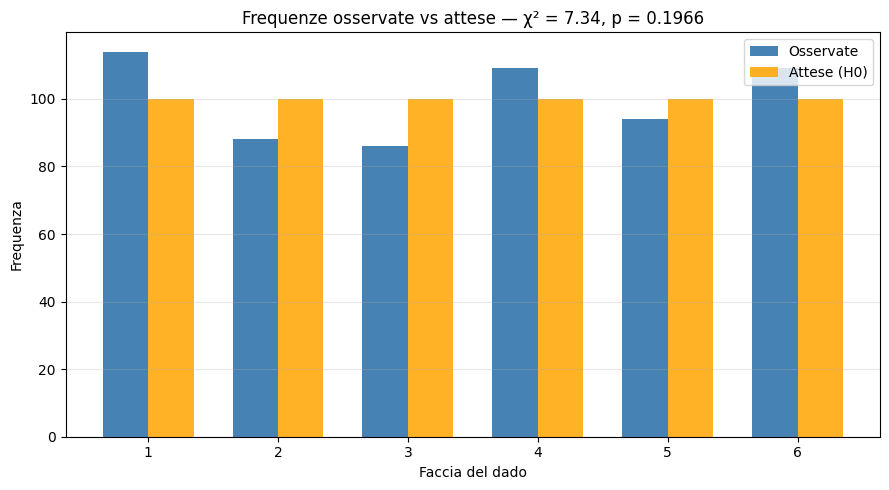

In [ ]:
# Visualizzazione: osservate vs attese
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, 7)
width = 0.35
ax.bar(x - width/2, obs.values, width, label="Osservate", color="steelblue")
ax.bar(x + width/2, exp, width, label="Attese (H0)", color="orange", alpha=0.85)
ax.set_xlabel("Faccia del dado")
ax.set_ylabel("Frequenza")
ax.set_title(f"Frequenze osservate vs attese — χ² = {chi2_stat:.2f}, p = {p_value:.4f}")
ax.set_xticks(x)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Estensioni del Test del Chi-Quadrato

Il test elementare appena visto può essere adattato a scenari più complessi:
- **Test di Adattamento per Leggi Continue**: utilizzato quando la distribuzione candidata $\phi_0$ è continua, quindi non è possibile contare le occorrenze dei singoli valori. In tal caso la procedure viene adattata andando a discretizzare la distribuzione:
    1. Binning: viene suddiviso il dominio della variabile in $k$ intervalli.
    2. Frequenze osservate: si contano quante osservazioni del campione cadono in ciascuna bin in modo da ottenere le frequenze osservate $O_j$.
    3. Frequenze attese: si calcola la probabilità $p_{0,j}$ che un'osservazione cada nel bin $j$ secondo la distribuzione nulla $\phi_0$. Per una distribuzione continua con densità $f_0(x)$, questo si ottiene integrando:
        $$p_{0,j}=P(X \in B_j)=\int_{B_j} f_0(x) \ dx$$

- **Test di Adattamento a Famiglie di Distribuzioni**: utilizzata per testare l'adattamento a una famiglia di distribuzioni, piuttosto che verificare una determinata distribuzione, lasciando guindi i parametri liberi. Un'esempio classico è il test di Gaussianità in cui l'ipotesi è:
    > $H_0: X \sim N(\mu, \sigma^2)$ con $\mu$ e $\sigma^2$ non specificati.
    
    La procedura è la seguente:
    1. Stima dei parametri: si stimano i parametri incogniti della distribuzione dal campione (es. $\hat \mu = \overline x$, $\hat \sigma^2=s^2$).
    2. Test standard: si esegue il test di adattamento del Chi-Quadrato usando come distribuzione nulla $\phi_0$ quella della famiglia specificata, ma con i parametri appena stimati.
    3. Correzione dei Gradi di Libertà: la distribuzione della statistica del test $W$ è ancora una Chi-Quadrato, ma i suoi gradi di libertà vengono ridotti.

    In tal caso siccome si stimeranno $s$ parametri per definire la distribuzione nulla $\phi_0$, la statistica test $W$ si distribuisce con un Chi-Quadrato con k-1-s gradi di libertà.

Per entrambe le estensioni valgono inoltre alcune considerazioni pratiche:

- **Strategia di binning**: a parità di $k$, il test è più potente e l'approssimazione alla $\chi^2$ è migliore se le frequenze attese $A_j$ sono più grandi possibile. Per questo motivo la strategia ottimale non è creare bin di larghezza uguale, ma **bin equiprobabili**, ovvero intervalli scelti in modo tale che la probabilità $p_{0,j}$ (e quindi la frequenza attesa $A_j$) sia la stessa per ogni bin. La potenza del test rimane comunque legata al numero e alla posizione dei bin scelti.

- **Uso pratico dei test di adattamento**: utilizzare test formali per verificare a priori o a posteriori le assunzioni di un modello (es. la Gaussianità dei residui) non è sempre una buona idea. Con campioni molto grandi questi test diventano "troppo potenti" e possono rigettare $H_0$ per deviazioni minime e praticamente irrilevanti. Spesso infatti non ci interessa se i dati siano *esattamente* Normali, ma se siano *sufficientemente vicini* alla Normalità perché le nostre procedure funzionino. Per questo motivo è spesso preferibile affiancare o sostituire il test formale con un controllo qualitativo e grafico (es. un Q-Q plot).

## Test del Chi-Quadrato per Tabelle di Contingenza

Questa è una delle applicazioni più comuni del test del Chi-Quadrato e serve a verificare se esista un'associazione tra due variabili categoriali. A differenze della regressione o dell'ANOVA, questa è un analisi simmetrica, non si definisce una variabile d'ingresso e una di uscita, ma si studia la relazione reciprova $X \iff Y$. L'obiettivo del test è determinare se due variabili categoriali sono statisticamente indipendenti o se sono associate, le ipotesi saranno:
- **Ipotesi Nulla ($H_0$)**: Le due variabili sono indipendenti. In termini di probabilità, la probabilità congiunta è il prodotto delle probabilità marginali: $P(X=i, Y=j)=P(X=i)P(X=j)$
- **Ipotesi alternativa ($H_1$)**: Le due variabili non sono indipendenti.

Notare che questo test non è parametrico siccome non fa alcuna ipotesi sulla famiglia di distribuzione, ciò lo rende meno potente di test come l'ANOVA se le assunzioni di quest'ultima sono soddisfatte.

La procedura si basa sul confronto tra le frequenze congiunte osservate nel campione e quelle che ci aspetteremmo in un'ipotetica situazione di indipendenza:
- **Frequenze osservate ($O_{ij}$)**: sono i conteggi effettivi per ogni cella della tabella di contingenza, ovvero il numero di osservazioni che presentano allo stesso tempo sia la categoria $i$ della prima variabile che la categoria $j$ della seconda.
- **Frequenze attese ($A_{ij}$)**: sono i conteggi che ci aspetteremmo in ogni cella se $H_0$ (ipotesi nulla d'indipendenza) fosse vera. Poiché le probabilit marginali sono incognite vengono stimate dai dati. La formula per le frequenze attese è:
    $$A_{ij}= \frac {\text{Totale osservazioni della categoria i (riga)} * \text{Totale osservazioni della categoria j (colonna)}} {\text{Totale generale (tabella)}}$$

Per misurare la discrepanza tra le frequenze osservate e quelle attese si usa la statistica test del Chi-Quadrato di Pearson:
$$
\chi^2 = \sum_{i=1}^m\sum_{j=1}^n \frac {(O_{ij}-A_{ij})^2} {A_{ij}}
$$

Notare che l'idea alla base è dovuta al fatto che $O_{ij}$ contiene il mondo reale, ovvero cosa noi stiamo effettivamente osservando, invece $A_{ij}$ contiene un mondo ipotetico, ovvero cosa osserveremmo se le due variabili fossero perfettamente indipendenti. La statistica test calcola proprio questa discrepanza, se $O_{ij} \approx A_{ij}$ per ogni cella allora significherà che $\chi^2 \approx 0$, ciò vuol dire che i due mondi si assomigliano quindi le variabili sono tra di loro indipendenti.

### Distribuzione della statistica e gradi di libertà

Sotto l'ipotesi nulla di indipendenza la statistica del test $W$ (cioè $\chi^2$) segue asintoticamente una distribuzione Chi-Quadrato con $(m-1)(n-1)$ gradi di libertà, dove $m$ è il numero di righe e $n$ il numero di colonne:
$$
W \sim^{H_0} \chi^2_{(m-1)(n-1)}
$$

Il numero di gradi di libertà si ricava dalla regola generale:
$$
\text{gdl} = (\text{numero di categorie}) - 1 - (\text{numero di parametri stimati})
$$
- Il numero totale di categorie (celle) è $m \cdot n$.
- Per stimare le frequenze attese abbiamo dovuto stimare le probabilità marginali: per le $m$ righe i parametri liberi sono $m-1$ (poiché la somma deve fare 1) e per le $n$ colonne sono $n-1$, quindi in totale $(m-1) + (n-1)$ parametri stimati.

Mettendo tutto insieme:
$$
\text{gdl} = mn - 1 - \big[(m-1) + (n-1)\big] = mn - m - n + 1 = (m-1)(n-1)
$$

**Note pratiche:**
- **Variabili continue**: se una o entrambe le variabili non sono discrete con poche categorie, devono prima essere discretizzate tramite binning.
- **Condizioni di validità**: come nel caso elementare, l'approssimazione alla $\chi^2$ è valida se le frequenze attese non sono troppo piccole (la regola pratica è che almeno l'80% delle celle abbia $A_{ij} \ge 5$ e tutte abbiano $A_{ij} \ge 1$).

## Versioni Esatte dei Test del Chi-Quadrato

L'approssimazione della statistica $W$ con una distribuzione $\chi^2$ è un risultato asintotico, valido quindi solo per grandi campioni. Quando le frequenze attese sono basse e la regola pratica (*rule of thumb*) non è rispettata, questa approssimazione non è più affidabile. In questi casi si ricorre a versioni esatte del test, che calcolano la distribuzione della statistica sotto $H_0$ senza fare affidamento sull'approssimazione. Questo si può ottenere in due modi:
- **Metodo esatto (esaustione)**: tramite calcolo combinatorio si enumerano tutti i possibili risultati e si calcola la probabilità esatta di ciascuno. È fattibile solo per problemi di piccole dimensioni.
- **Simulazione Monte Carlo (MCS)**: si genera un gran numero di campioni casuali dalla distribuzione nulla $\phi_0$, si calcola la statistica del test per ciascuno e si costruisce una distribuzione empirica che approssima quella vera.

### Test Esatto di Goodness-of-Fit

Supponiamo di voler eseguire un test di adattamento ma le frequenze attese sono troppo piccole. Ad esempio, con un campione di $n = 20$ studenti vogliamo testare se la distribuzione del loro titolo di studio si conforma a una $\phi_0$ data. Se le frequenze attese $A_j = n \cdot p_{0,j}$ risultano essere, ad esempio, $[2, 10, 6, 2]$, la regola pratica per l'uso della $\chi^2$ non è rispettata e quindi non possiamo fidarci del p-value ottenuto da una distribuzione $\chi^2_3$. Per calcolare il p-value corretto dobbiamo trovare la vera distribuzione della statistica $W$ sotto $H_0$: con una simulazione Monte Carlo, ad esempio, possiamo generare 100.000 campioni da $\phi_0$, calcolare $W$ per ciascuno e usare la distribuzione empirica di questi valori per calcolare il p-value.

### Il Test Esatto di Fisher per Tabelle 2x2

Il test esatto di Fisher è la soluzione combinatoria esatta per il test di indipendenza in una tabella di contingenza $2 \times 2$. È particolarmente utile quando le numerosità campionarie sono piccole.

L'idea fondamentale è che, invece di usare la statistica $W$, il test si concentra su una delle quattro celle della tabella, tipicamente quella in alto a sinistra ($O_{11}$). Il punto chiave è che, una volta **fissati i totali marginali** della tabella, il valore di una singola cella determina i valori di tutte le altre.

|                    | Colonna 1 | Colonna 2 | Totale Riga |
|--------------------|-----------|-----------|-------------|
| **Riga 1**         | $O_{11}$  | $O_{12}$  | $c$         |
| **Riga 2**         | $O_{21}$  | $O_{22}$  | $d$         |
| **Totale Colonna** | $a$       | $b$       | $n$         |

Il problema è analogo a un'estrazione da un'urna: immaginiamo un'urna con $n$ palline, di cui $a$ nere (colonna 1) e $b$ bianche (colonna 2). Se estraiamo $c$ palline (la prima riga), il numero di palline nere estratte ($k$) corrisponde al valore di $O_{11}$. Questa logica porta direttamente alla distribuzione di probabilità esatta.

Assumendo l'ipotesi nulla $H_0$ di indipendenza e condizionando ai totali marginali, la probabilità di osservare un valore $k$ nella cella $(1,1)$ di una tabella $2 \times 2$ segue la distribuzione **Ipergeometrica**:
$$
P(O_{11} = k \mid H_0, \text{marginali}) = \frac {\binom a k \binom b {c-k}} {\binom n c}
$$

**Calcolo del p-value**: il test è tipicamente bilaterale. Il p-value si calcola sommando le probabilità di tutti i risultati altrettanto o più "estremi" (rari) di quello osservato. Se la distribuzione è simmetrica e osserviamo ad esempio $O_{11} = 1$, il p-value sarà la somma delle probabilità nelle due code, quindi $P(O_{11} \le 1) + P(O_{11} \ge 7)$.